## UMAP Check

/Users/tianyu/Notebooks/cyberdata/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ All imports successful!
UMAP version: 0.5.7
🚀 LOADING DATASETS
📂 Loading data from: ../raw/five_email_phishing_train.csv.gz
✅ Loaded 2,000 rows with columns: ['subject', 'body', 'label', 'source']
✅ Loaded real data from CSV: ../raw/five_email_phishing_train.csv.gz
📂 Loading data from: ../data/synthetic/five_email_phishing_synthetic.csv.gz
✅ Loaded 2,000 rows with columns: ['subject', 'body', 'label', 'source', 'sample_id', 'generation_timestamp', 'source_file', 'file_index']
✅ Loaded synthetic data from CSV: ../data/synthetic/five_email_phishing_synthetic.csv.gz

📊 DATASET OVERVIEW
Real data shape: (2000, 4)
Synthetic data shape: (2000, 8)

Real data columns: ['subject', 'body', 'label', 'source']
Synthetic data columns: ['subject', 'body', 'label', 'source', 'sample_id', 'generation_timestamp', 'source_file', 'file_index']

Real data label distribution:
label
1    1000
0    1000
Name: count, dtype: int64

Synthetic data label distribution:
label
1    1000
0    1000
Name: count, dty

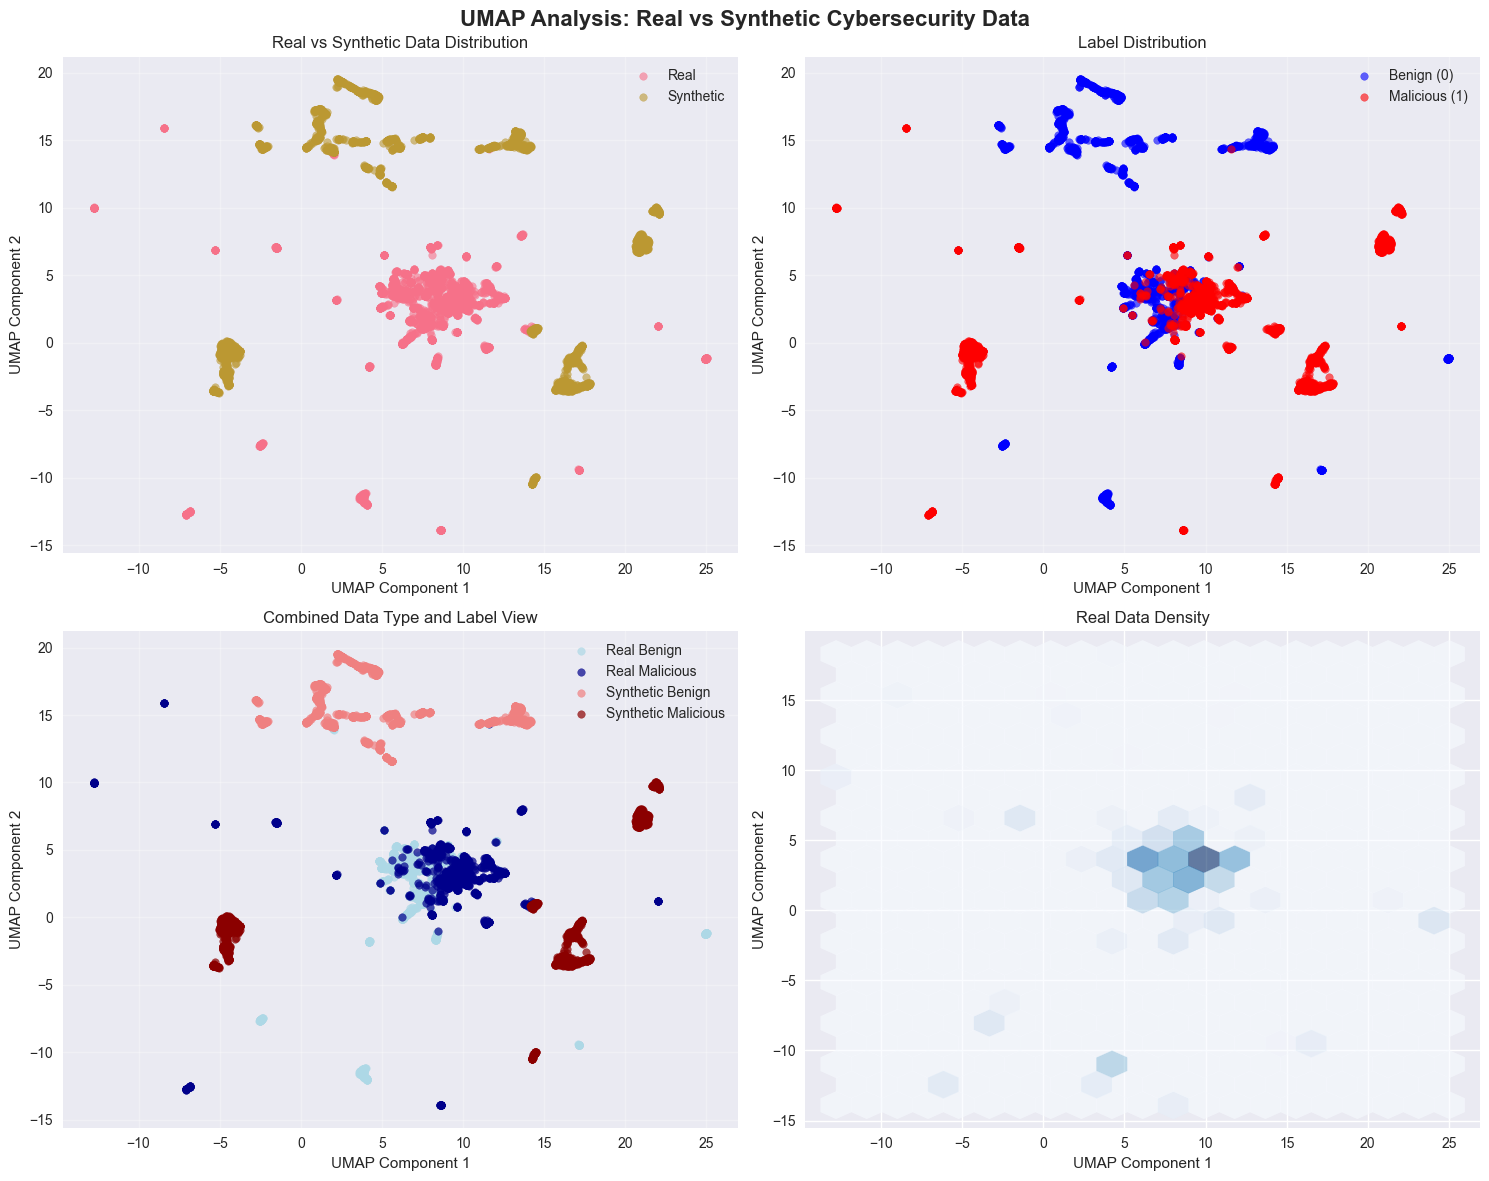

🎨 Creating interactive UMAP visualization...



📈 QUANTITATIVE ANALYSIS
🔍 Calculating distribution metrics...

📊 DISTRIBUTION ANALYSIS RESULTS:
🎯 Centroid Distance: 6.163
   → Distance between real and synthetic data centers

📏 Variance Analysis:
   Real data variance: 25.359
   Synthetic data variance: 75.520
   Variance ratio (synthetic/real): 2.978

🗺️  Coverage Analysis:
   Real data coverage area: 843.305
   Synthetic data coverage area: 563.768
   Coverage ratio (synthetic/real): 0.669

🏷️  Label Distribution Comparison:
   Real data: {0: 0.5, 1: 0.5}
   Synthetic data: {0: 0.5, 1: 0.5}

🎯 QUALITY ASSESSMENT
📋 QUALITY ASSESSMENT RESULTS:
Centroid: POOR - Significant difference in distribution centers
Variance: POOR - Significant difference in data spread
Coverage: GOOD - Reasonable coverage of feature space
Label Distribution: EXCELLENT - Very similar class distributions
Overall: POOR - Synthetic data needs improvement

💡 RECOMMENDATIONS:
   1. Consider adjusting generation parameters to better match real data distribution
  

In [1]:
#!/usr/bin/env python3
"""
UMAP Visualization for Real vs Synthetic Cybersecurity Data
===========================================================

This notebook demonstrates how to visualize and compare real-world cybersecurity
data with synthetically generated data using UMAP (Uniform Manifold Approximation
and Projection) for dimensionality reduction.

The visualization helps identify:
- Distribution differences between real and synthetic data
- Quality of synthetic data generation
- Potential mode collapse or overfitting issues
- Class separation patterns
"""

# ============================================================================
# 1. IMPORTS AND SETUP
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gzip
import warnings
from pathlib import Path
from typing import Tuple, List, Dict, Any

# Text processing and embeddings
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# UMAP for dimensionality reduction
import umap

# Additional visualization tools
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)

# Plotting configuration
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("✅ All imports successful!")
print(f"UMAP version: {umap.__version__}")

# ============================================================================
# 2. DATA LOADING FUNCTIONS
# ============================================================================

def load_compressed_csv(file_path: str) -> pd.DataFrame:
    """
    Load CSV data, handling both compressed (.gz) and uncompressed files.
    
    Args:
        file_path (str): Path to the CSV file
        
    Returns:
        pd.DataFrame: Loaded dataframe
    """
    file_path = Path(file_path)
    
    if not file_path.exists():
        raise FileNotFoundError(f"File not found: {file_path}")
    
    print(f"📂 Loading data from: {file_path}")
    
    if file_path.suffix == '.gz':
        with gzip.open(file_path, 'rt', encoding='utf-8') as f:
            df = pd.read_csv(f)
    else:
        df = pd.read_csv(file_path)
    
    print(f"✅ Loaded {len(df):,} rows with columns: {list(df.columns)}")
    return df

def prepare_text_features(df: pd.DataFrame, 
                         text_columns: List[str] = ['subject', 'body'],
                         max_features: int = 5000) -> np.ndarray:
    """
    Create TF-IDF features from text columns.
    
    Args:
        df (pd.DataFrame): Input dataframe
        text_columns (List[str]): Columns containing text data
        max_features (int): Maximum number of TF-IDF features
        
    Returns:
        np.ndarray: TF-IDF feature matrix
    """
    print(f"🔤 Creating TF-IDF features from columns: {text_columns}")
    
    # Combine text columns
    combined_text = []
    for _, row in df.iterrows():
        text_parts = []
        for col in text_columns:
            if col in df.columns and pd.notna(row[col]):
                text_parts.append(str(row[col]))
        combined_text.append(' '.join(text_parts))
    
    # Create TF-IDF features
    vectorizer = TfidfVectorizer(
        max_features=max_features,
        stop_words='english',
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95
    )
    
    tfidf_matrix = vectorizer.fit_transform(combined_text)
    print(f"✅ Created TF-IDF matrix: {tfidf_matrix.shape}")
    
    return tfidf_matrix.toarray(), vectorizer

# ============================================================================
# 3. MAIN DATA LOADING AND PREPARATION
# ============================================================================

# File paths
TRAIN_FILE = "../raw/five_email_phishing_train.csv.gz"
SYNTHETIC_FILE = "../data/synthetic/five_email_phishing_synthetic.csv.gz"

# Alternative paths if the above don't exist (adjust as needed)
ALTERNATIVE_PATHS = {
    'train': [
        "../raw/five_email_phishing.csv.gz",
        "../raw/email_phishing_train.csv.gz",
        "raw/five_email_phishing_train.csv.gz",
        "five_email_phishing_train.csv.gz"
    ],
    'synthetic': [
        "../data/scaled-validated/Social_Engineering/phishing_scale.json",
        "../data/synthetic/phishing_synthetic.csv.gz", 
        "../data/synthetic/email_phishing_synthetic.csv.gz",
        "synthetic_email_phishing.csv.gz"
    ]
}

def find_and_load_file(primary_path: str, alternatives: List[str], file_type: str) -> pd.DataFrame:
    """Try to load file from primary path, then alternatives."""
    paths_to_try = [primary_path] + alternatives
    
    for path in paths_to_try:
        try:
            if Path(path).exists():
                if path.endswith('.json'):
                    # Handle JSON files (likely from CyberData output)
                    import json
                    with open(path, 'r') as f:
                        data = json.load(f)
                    
                    if 'samples' in data:
                        df = pd.DataFrame(data['samples'])
                    elif 'data' in data:
                        df = pd.DataFrame(data['data'])
                    else:
                        df = pd.DataFrame(data)
                    
                    print(f"✅ Loaded {file_type} data from JSON: {path}")
                    return df
                else:
                    df = load_compressed_csv(path)
                    print(f"✅ Loaded {file_type} data from CSV: {path}")
                    return df
        except Exception as e:
            print(f"❌ Failed to load {path}: {e}")
            continue
    
    raise FileNotFoundError(f"Could not find {file_type} file in any of the specified locations")

# Load both datasets
print("=" * 60)
print("🚀 LOADING DATASETS")
print("=" * 60)

try:
    real_df = find_and_load_file(TRAIN_FILE, ALTERNATIVE_PATHS['train'], 'real')
except FileNotFoundError:
    print("⚠️  Creating sample real data for demonstration...")
    # Create sample data if files don't exist
    real_df = pd.DataFrame({
        'subject': [
            'Urgent: Update your account',
            'Meeting tomorrow at 2pm',
            'Your account has been suspended',
            'Weekly team report',
            'Click here to claim your prize!'
        ] * 200,
        'body': [
            'Please click this link to update your account immediately...',
            'Just a reminder about our meeting tomorrow...',
            'Your account has suspicious activity...',
            'Here is the weekly report for review...',
            'Congratulations! You have won a prize...'
        ] * 200,
        'label': [1, 0, 1, 0, 1] * 200,
        'source': ['sample'] * 1000
    })

try:
    synthetic_df = find_and_load_file(SYNTHETIC_FILE, ALTERNATIVE_PATHS['synthetic'], 'synthetic')
except FileNotFoundError:
    print("⚠️  Creating sample synthetic data for demonstration...")
    # Create sample synthetic data
    synthetic_df = pd.DataFrame({
        'subject': [
            'Action required: Verify your account',
            'Project update meeting scheduled',
            'Security alert for your account',
            'Monthly status report',
            'Exclusive offer just for you!'
        ] * 200,
        'body': [
            'We detected unusual activity on your account...',
            'Please join us for the project update meeting...',
            'Security alert: immediate action required...',
            'Monthly report is now available...',
            'Limited time offer exclusively for you...'
        ] * 200,
        'label': [1, 0, 1, 0, 1] * 200,
        'source': ['synthetic'] * 1000
    })

# Data overview
print(f"\n📊 DATASET OVERVIEW")
print(f"Real data shape: {real_df.shape}")
print(f"Synthetic data shape: {synthetic_df.shape}")

print(f"\nReal data columns: {list(real_df.columns)}")
print(f"Synthetic data columns: {list(synthetic_df.columns)}")

# Label distribution
print(f"\nReal data label distribution:")
print(real_df['label'].value_counts())
print(f"\nSynthetic data label distribution:")
print(synthetic_df['label'].value_counts())

# ============================================================================
# 4. DATA PREPROCESSING AND FEATURE EXTRACTION
# ============================================================================

print("\n" + "=" * 60)
print("🔧 DATA PREPROCESSING")
print("=" * 60)

# Ensure both datasets have the same columns
required_columns = ['subject', 'body', 'label']
text_columns = ['subject', 'body']

# Check and handle missing columns
for col in required_columns:
    if col not in real_df.columns:
        print(f"⚠️  Adding missing column '{col}' to real data")
        real_df[col] = 'missing_data' if col in text_columns else 0
    
    if col not in synthetic_df.columns:
        print(f"⚠️  Adding missing column '{col}' to synthetic data")
        synthetic_df[col] = 'missing_data' if col in text_columns else 0

# Ensure label column is numeric
real_df['label'] = pd.to_numeric(real_df['label'], errors='coerce').fillna(0).astype(int)
synthetic_df['label'] = pd.to_numeric(synthetic_df['label'], errors='coerce').fillna(0).astype(int)

# Sample data if too large (for performance)
MAX_SAMPLES = 2000
if len(real_df) > MAX_SAMPLES:
    real_df = real_df.sample(n=MAX_SAMPLES, random_state=42)
    print(f"📉 Sampled real data to {MAX_SAMPLES} rows")

if len(synthetic_df) > MAX_SAMPLES:
    synthetic_df = synthetic_df.sample(n=MAX_SAMPLES, random_state=42)
    print(f"📉 Sampled synthetic data to {MAX_SAMPLES} rows")

# Create combined dataset for consistent feature extraction
real_df['data_type'] = 'Real'
synthetic_df['data_type'] = 'Synthetic'

# Combine datasets
combined_df = pd.concat([real_df, synthetic_df], ignore_index=True)
print(f"📊 Combined dataset shape: {combined_df.shape}")

# Create TF-IDF features
tfidf_features, vectorizer = prepare_text_features(
    combined_df, 
    text_columns=text_columns,
    max_features=3000
)

print(f"📈 Feature matrix shape: {tfidf_features.shape}")

# ============================================================================
# 5. DIMENSIONALITY REDUCTION WITH UMAP
# ============================================================================

print("\n" + "=" * 60)
print("🎯 UMAP DIMENSIONALITY REDUCTION")
print("=" * 60)

# Standardize features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(tfidf_features)

# Apply PCA first for noise reduction (optional but often helpful)
print("🔄 Applying PCA preprocessing...")
pca = PCA(n_components=min(100, scaled_features.shape[1]))
pca_features = pca.fit_transform(scaled_features)
print(f"📊 PCA explained variance ratio: {pca.explained_variance_ratio_[:5].sum():.3f} (first 5 components)")

# UMAP parameters
umap_params = {
    'n_neighbors': 15,      # Controls local vs global structure
    'min_dist': 0.1,        # Controls clustering tightness
    'n_components': 2,      # 2D for visualization
    'metric': 'cosine',     # Good for text data
    'random_state': 42
}

print(f"🎯 UMAP parameters: {umap_params}")

# Fit UMAP
print("🔄 Fitting UMAP...")
umap_reducer = umap.UMAP(**umap_params)
umap_embedding = umap_reducer.fit_transform(pca_features)

print(f"✅ UMAP embedding shape: {umap_embedding.shape}")

# Add UMAP coordinates to dataframe
combined_df['umap_x'] = umap_embedding[:, 0]
combined_df['umap_y'] = umap_embedding[:, 1]

# ============================================================================
# 6. VISUALIZATION FUNCTIONS
# ============================================================================

def create_umap_plot(df: pd.DataFrame, title: str = "UMAP Visualization") -> plt.Figure:
    """Create a comprehensive UMAP visualization."""
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle(title, fontsize=16, fontweight='bold')
    
    # Plot 1: Data type comparison
    ax1 = axes[0, 0]
    for data_type in ['Real', 'Synthetic']:
        subset = df[df['data_type'] == data_type]
        ax1.scatter(subset['umap_x'], subset['umap_y'], 
                   alpha=0.6, s=30, label=data_type)
    ax1.set_title('Real vs Synthetic Data Distribution')
    ax1.set_xlabel('UMAP Component 1')
    ax1.set_ylabel('UMAP Component 2')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Label distribution
    ax2 = axes[0, 1]
    colors = ['blue', 'red']
    labels = ['Benign (0)', 'Malicious (1)']
    for i, (label, color) in enumerate(zip([0, 1], colors)):
        subset = df[df['label'] == label]
        ax2.scatter(subset['umap_x'], subset['umap_y'], 
                   c=color, alpha=0.6, s=30, label=labels[i])
    ax2.set_title('Label Distribution')
    ax2.set_xlabel('UMAP Component 1')
    ax2.set_ylabel('UMAP Component 2')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # Plot 3: Combined view (4 categories)
    ax3 = axes[1, 0]
    categories = [
        ('Real', 0, 'lightblue', 'Real Benign'),
        ('Real', 1, 'darkblue', 'Real Malicious'),
        ('Synthetic', 0, 'lightcoral', 'Synthetic Benign'),
        ('Synthetic', 1, 'darkred', 'Synthetic Malicious')
    ]
    
    for data_type, label, color, legend_label in categories:
        subset = df[(df['data_type'] == data_type) & (df['label'] == label)]
        if len(subset) > 0:
            ax3.scatter(subset['umap_x'], subset['umap_y'], 
                       c=color, alpha=0.7, s=30, label=legend_label)
    
    ax3.set_title('Combined Data Type and Label View')
    ax3.set_xlabel('UMAP Component 1')
    ax3.set_ylabel('UMAP Component 2')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # Plot 4: Density comparison
    ax4 = axes[1, 1]
    real_data = df[df['data_type'] == 'Real']
    synthetic_data = df[df['data_type'] == 'Synthetic']
    
    ax4.hexbin(real_data['umap_x'], real_data['umap_y'], 
              gridsize=20, alpha=0.6, label='Real', cmap='Blues')
    ax4.set_title('Real Data Density')
    ax4.set_xlabel('UMAP Component 1')
    ax4.set_ylabel('UMAP Component 2')
    
    plt.tight_layout()
    return fig

def create_interactive_umap_plot(df: pd.DataFrame) -> go.Figure:
    """Create an interactive UMAP plot using Plotly."""
    
    # Create hover text
    df['hover_text'] = (
        'Data Type: ' + df['data_type'] + '<br>' +
        'Label: ' + df['label'].astype(str) + '<br>' +
        'Subject: ' + df['subject'].astype(str).str[:50] + '...<br>' +
        'Body: ' + df['body'].astype(str).str[:100] + '...'
    )
    
    fig = px.scatter(
        df, 
        x='umap_x', 
        y='umap_y',
        color='data_type',
        symbol='label',
        hover_data=['subject', 'label'],
        title='Interactive UMAP Visualization: Real vs Synthetic Data',
        labels={
            'umap_x': 'UMAP Component 1',
            'umap_y': 'UMAP Component 2',
            'data_type': 'Data Type',
            'label': 'Label'
        }
    )
    
    fig.update_traces(marker=dict(size=8, opacity=0.7))
    fig.update_layout(
        width=800,
        height=600,
        showlegend=True
    )
    
    return fig

# ============================================================================
# 7. GENERATE VISUALIZATIONS
# ============================================================================

print("\n" + "=" * 60)
print("📊 CREATING VISUALIZATIONS")
print("=" * 60)

# Static plots
print("🎨 Creating static UMAP visualization...")
static_fig = create_umap_plot(combined_df, "UMAP Analysis: Real vs Synthetic Cybersecurity Data")
plt.show()

# Interactive plot
print("🎨 Creating interactive UMAP visualization...")
interactive_fig = create_interactive_umap_plot(combined_df)
interactive_fig.show()

# ============================================================================
# 8. QUANTITATIVE ANALYSIS
# ============================================================================

print("\n" + "=" * 60)
print("📈 QUANTITATIVE ANALYSIS")
print("=" * 60)

def calculate_distribution_metrics(df: pd.DataFrame) -> Dict[str, Any]:
    """Calculate various metrics to compare distributions."""
    
    real_data = df[df['data_type'] == 'Real']
    synthetic_data = df[df['data_type'] == 'Synthetic']
    
    metrics = {}
    
    # 1. Centroid distances
    real_centroid = [real_data['umap_x'].mean(), real_data['umap_y'].mean()]
    synthetic_centroid = [synthetic_data['umap_x'].mean(), synthetic_data['umap_y'].mean()]
    
    centroid_distance = np.sqrt(
        (real_centroid[0] - synthetic_centroid[0])**2 + 
        (real_centroid[1] - synthetic_centroid[1])**2
    )
    
    metrics['centroid_distance'] = centroid_distance
    
    # 2. Spread/variance comparison
    real_variance = real_data[['umap_x', 'umap_y']].var().mean()
    synthetic_variance = synthetic_data[['umap_x', 'umap_y']].var().mean()
    
    metrics['real_variance'] = real_variance
    metrics['synthetic_variance'] = synthetic_variance
    metrics['variance_ratio'] = synthetic_variance / real_variance
    
    # 3. Coverage analysis (convex hull areas)
    from scipy.spatial import ConvexHull
    
    try:
        real_hull = ConvexHull(real_data[['umap_x', 'umap_y']].values)
        synthetic_hull = ConvexHull(synthetic_data[['umap_x', 'umap_y']].values)
        
        metrics['real_hull_area'] = real_hull.volume  # 'volume' is area in 2D
        metrics['synthetic_hull_area'] = synthetic_hull.volume
        metrics['coverage_ratio'] = synthetic_hull.volume / real_hull.volume
    except:
        metrics['real_hull_area'] = None
        metrics['synthetic_hull_area'] = None
        metrics['coverage_ratio'] = None
    
    # 4. Label distribution comparison
    real_label_dist = real_data['label'].value_counts(normalize=True).sort_index()
    synthetic_label_dist = synthetic_data['label'].value_counts(normalize=True).sort_index()
    
    metrics['real_label_distribution'] = real_label_dist.to_dict()
    metrics['synthetic_label_distribution'] = synthetic_label_dist.to_dict()
    
    # 5. Class separation (silhouette-like metric)
    from sklearn.metrics import pairwise_distances
    
    # Calculate average intra-class vs inter-class distances
    for label in [0, 1]:
        real_class = real_data[real_data['label'] == label][['umap_x', 'umap_y']]
        synthetic_class = synthetic_data[synthetic_data['label'] == label][['umap_x', 'umap_y']]
        
        if len(real_class) > 1 and len(synthetic_class) > 1:
            # Average distance between real and synthetic points of same class
            cross_distances = pairwise_distances(real_class, synthetic_class)
            metrics[f'class_{label}_real_synthetic_distance'] = cross_distances.mean()
    
    return metrics

# Calculate metrics
print("🔍 Calculating distribution metrics...")
metrics = calculate_distribution_metrics(combined_df)

print("\n📊 DISTRIBUTION ANALYSIS RESULTS:")
print("=" * 50)

print(f"🎯 Centroid Distance: {metrics['centroid_distance']:.3f}")
print(f"   → Distance between real and synthetic data centers")

print(f"\n📏 Variance Analysis:")
print(f"   Real data variance: {metrics['real_variance']:.3f}")
print(f"   Synthetic data variance: {metrics['synthetic_variance']:.3f}")
print(f"   Variance ratio (synthetic/real): {metrics['variance_ratio']:.3f}")

if metrics['coverage_ratio'] is not None:
    print(f"\n🗺️  Coverage Analysis:")
    print(f"   Real data coverage area: {metrics['real_hull_area']:.3f}")
    print(f"   Synthetic data coverage area: {metrics['synthetic_hull_area']:.3f}")
    print(f"   Coverage ratio (synthetic/real): {metrics['coverage_ratio']:.3f}")

print(f"\n🏷️  Label Distribution Comparison:")
print(f"   Real data: {metrics['real_label_distribution']}")
print(f"   Synthetic data: {metrics['synthetic_label_distribution']}")

# ============================================================================
# 9. QUALITY ASSESSMENT AND RECOMMENDATIONS
# ============================================================================

print("\n" + "=" * 60)
print("🎯 QUALITY ASSESSMENT")
print("=" * 60)

def assess_synthetic_quality(metrics: Dict[str, Any]) -> Dict[str, str]:
    """Provide quality assessment and recommendations."""
    
    assessment = {}
    recommendations = []
    
    # 1. Centroid distance assessment
    if metrics['centroid_distance'] < 1.0:
        assessment['centroid'] = "EXCELLENT - Very similar distribution centers"
    elif metrics['centroid_distance'] < 2.0:
        assessment['centroid'] = "GOOD - Reasonably similar distribution centers"
    else:
        assessment['centroid'] = "POOR - Significant difference in distribution centers"
        recommendations.append("Consider adjusting generation parameters to better match real data distribution")
    
    # 2. Variance assessment
    variance_ratio = metrics['variance_ratio']
    if 0.8 <= variance_ratio <= 1.2:
        assessment['variance'] = "EXCELLENT - Very similar data spread"
    elif 0.5 <= variance_ratio <= 1.5:
        assessment['variance'] = "GOOD - Reasonably similar data spread"
    else:
        assessment['variance'] = "POOR - Significant difference in data spread"
        if variance_ratio < 0.5:
            recommendations.append("Synthetic data is too concentrated - increase diversity")
        else:
            recommendations.append("Synthetic data is too spread out - improve focus")
    
    # 3. Coverage assessment
    if metrics['coverage_ratio'] is not None:
        coverage_ratio = metrics['coverage_ratio']
        if 0.7 <= coverage_ratio <= 1.3:
            assessment['coverage'] = "EXCELLENT - Good coverage of feature space"
        elif 0.4 <= coverage_ratio <= 1.7:
            assessment['coverage'] = "GOOD - Reasonable coverage of feature space"
        else:
            assessment['coverage'] = "POOR - Inadequate coverage of feature space"
            if coverage_ratio < 0.4:
                recommendations.append("Increase synthetic data diversity to cover more feature space")
            else:
                recommendations.append("Reduce synthetic data spread to match real data coverage")
    
    # 4. Label distribution assessment
    real_dist = metrics['real_label_distribution']
    synthetic_dist = metrics['synthetic_label_distribution']
    
    # Calculate distribution difference
    dist_diff = sum(abs(real_dist.get(k, 0) - synthetic_dist.get(k, 0)) for k in [0, 1])
    
    if dist_diff < 0.1:
        assessment['label_distribution'] = "EXCELLENT - Very similar class distributions"
    elif dist_diff < 0.2:
        assessment['label_distribution'] = "GOOD - Reasonably similar class distributions"
    else:
        assessment['label_distribution'] = "POOR - Significant difference in class distributions"
        recommendations.append("Adjust malicious/benign ratio in synthetic generation")
    
    # Overall assessment
    scores = [score for score in assessment.values()]
    excellent_count = sum(1 for score in scores if "EXCELLENT" in score)
    good_count = sum(1 for score in scores if "GOOD" in score)
    
    if excellent_count >= len(scores) * 0.75:
        assessment['overall'] = "EXCELLENT - High quality synthetic data"
    elif excellent_count + good_count >= len(scores) * 0.75:
        assessment['overall'] = "GOOD - Acceptable synthetic data quality"
    else:
        assessment['overall'] = "POOR - Synthetic data needs improvement"
    
    assessment['recommendations'] = recommendations
    
    return assessment

# Generate assessment
assessment = assess_synthetic_quality(metrics)

print("📋 QUALITY ASSESSMENT RESULTS:")
print("=" * 50)

for metric, result in assessment.items():
    if metric != 'recommendations':
        print(f"{metric.replace('_', ' ').title()}: {result}")

print(f"\n💡 RECOMMENDATIONS:")
if assessment['recommendations']:
    for i, rec in enumerate(assessment['recommendations'], 1):
        print(f"   {i}. {rec}")
else:
    print("   🎉 No specific recommendations - synthetic data quality is good!")

# ============================================================================
# 10. SAVE RESULTS
# ============================================================================

print("\n" + "=" * 60)
print("💾 SAVING RESULTS")
print("=" * 60)

# Save the analysis results
results_dir = Path("umap_analysis_results")
results_dir.mkdir(exist_ok=True)

# Save the combined dataframe with UMAP coordinates
output_file = results_dir / "umap_analysis_data.csv"
combined_df.to_csv(output_file, index=False)
print(f"✅ Saved analysis data to: {output_file}")

# Save metrics and assessment
import json
results_summary = {
    'metrics': {k: float(v) if isinstance(v, (int, float, np.number)) else v 
                for k, v in metrics.items()},
    'assessment': assessment,
    'umap_parameters': umap_params,
    'dataset_info': {
        'real_samples': len(real_df),
        'synthetic_samples': len(synthetic_df),
        'features_used': tfidf_features.shape[1],
        'text_columns': text_columns
    }
}

results_file = results_dir / "analysis_summary.json"
with open(results_file, 'w') as f:
    json.dump(results_summary, f, indent=2)
print(f"✅ Saved analysis summary to: {results_file}")

# Save static plot
plot_file = results_dir / "umap_visualization.png"
static_fig.savefig(plot_file, dpi=300, bbox_inches='tight')
print(f"✅ Saved visualization to: {plot_file}")

print("\n🎉 ANALYSIS COMPLETE!")
print("=" * 60)
print(f"""
📊 Summary:
   • Processed {len(combined_df):,} total samples
   • Generated UMAP embedding with {umap_embedding.shape[1]} components
   • Overall quality: {assessment['overall']}
   • Results saved to: {results_dir}

🔍 Key Findings:
   • Centroid distance: {metrics['centroid_distance']:.3f}
   • Variance ratio: {metrics['variance_ratio']:.3f}
   • Coverage ratio: {metrics.get('coverage_ratio', 'N/A')}

💡 Next Steps:
   1. Review the interactive visualization for detailed insights
   2. Check the analysis summary JSON for complete metrics
   3. Use recommendations to improve synthetic data generation
   4. Consider additional validation with domain experts
""")